# 10.2 · Ratio tests and robust correspondence

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain ratio tests and robust correspondence using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[07 · Geometric Transformations](../../07-geometric-transformations/README.md), [09 · Feature Detection](../../09-feature-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A descriptor turns a neighborhood into a vector or bit string. Matching asks which vectors likely describe the same physical point. A nearest neighbor is only a proposal: geometry is needed to reject accidental visual similarities.

## 2. Intuition

The ratio test compares the nearest match distance with the second nearest. A ratio near one means the best candidate is ambiguous. Cross-checking asks whether the match is mutual; it is a different filter. Neither resolves repeated texture or guarantees a correct correspondence.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 10
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
d_1/d_2<\tau
$$

d1 is the nearest descriptor distance, d2 the second nearest and τ the chosen ratio threshold. Distances 12 and 30 produce 0.4 and pass τ=0.75. Zero second-neighbor distance is ambiguous and should not be divided blindly.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
best, second, ratio_threshold = 12.0, 30.0, 0.75
accepted = second > 0 and best / second < ratio_threshold
assert accepted
print(accepted)

True


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab detects ORB or SIFT features in a generated texture and its translated view, filters matches, estimates a RANSAC homography and compares translation with known truth.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def matching(lesson, seed, amount):
    rng = np.random.default_rng(seed)
    first = rng.integers(0, 256, (128, 128), dtype=np.uint8)
    first = cv2.GaussianBlur(first, (3, 3), 0)
    true_h = np.array([[1, 0, 6], [0, 1, 4], [0, 0, 1.0]], float)
    second = cv2.warpPerspective(first, true_h, (128, 128))
    detector = (
        cv2.SIFT_create(nfeatures=300)
        if lesson == 1
        else cv2.ORB_create(nfeatures=300, edgeThreshold=8, fastThreshold=5)
    )
    kp1, d1 = detector.detectAndCompute(first, None)
    kp2, d2 = detector.detectAndCompute(second, None)
    norm = cv2.NORM_L2 if lesson == 1 else cv2.NORM_HAMMING
    pairs = cv2.BFMatcher(norm).knnMatch(d1, d2, k=2)
    good = [
        pair[0]
        for pair in pairs
        if len(pair) == 2 and pair[0].distance < min(0.95, 0.75 * amount) * pair[1].distance
    ]
    view = cv2.drawMatches(first, kp1, second, kp2, good[:30], None, flags=2)
    metrics = {"ratio_test_matches": len(good)}
    if len(good) >= 4:
        a = np.float32([kp1[m.queryIdx].pt for m in good])
        b = np.float32([kp2[m.trainIdx].pt for m in good])
        estimated, inliers = cv2.findHomography(a, b, cv2.RANSAC, 2.0)
        if estimated is not None:
            metrics["ransac_inliers"] = int(inliers.sum())
            metrics["translation_error_px"] = float(
                np.linalg.norm(estimated[:2, 2] - true_h[:2, 2])
            )
    return Result(
        "10 · Descriptors, ratio test and RANSAC",
        {"First": first, "Transformed": second, "Matches": cv2.cvtColor(view, cv2.COLOR_BGR2RGB)},
        metrics=metrics,
        notes="Known synthetic translation supplies geometric ground truth; repetitive real scenes can remain ambiguous.",
    )

{
  "ratio_test_matches": 247,
  "ransac_inliers": 247,
  "translation_error_px": 0.0017333045244734434
}
Known synthetic translation supplies geometric ground truth; repetitive real scenes can remain ambiguous.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import fit_homography

display(Code(inspect.getsource(fit_homography), language="python"))

def fit_homography(source, destination):
    """Normalized direct linear transform for at least four point pairs."""
    source, destination = np.asarray(source, float), np.asarray(destination, float)
    if source.shape != destination.shape or len(source) < 4:
        raise ValueError("Need four or more paired xy points.")

    def normalize(points):
        center = points.mean(0)
        scale = np.sqrt(2) / max(np.linalg.norm(points - center, axis=1).mean(), 1e-12)
        transform = np.array(
            [[scale, 0, -scale * center[0]], [0, scale, -scale * center[1]], [0, 0, 1]]
        )
        return apply_homography(points, transform), transform

    a, ta = normalize(source)
    b, tb = normalize(destination)
    design = []
    for (x, y), (u, v) in zip(a, b, strict=True):
        design.extend(
            [[-x, -y, -1, 0, 0, 0, u * x, u * y, u], [0, 0, 0, -x, -y, -1, v * x, v * y, v]]
        )
    _, _, vt = np.linalg.svd(design)
    h = np.linalg.inv(tb) @ vt[-1].reshape(3, 3) @ ta
    return h / h[2, 2]

## 8. Experiment

Add repeated tiles and increase viewpoint change. Record keypoints, accepted matches, inliers and reprojection error separately.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "ratio_test_matches": 247,
    "ransac_inliers": 247,
    "translation_error_px": 0.0017333045244734434
  },
  "second_seed": {
    "ratio_test_matches": 240,
    "ransac_inliers": 240,
    "translation_error_px": 0.0018603587686043682
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

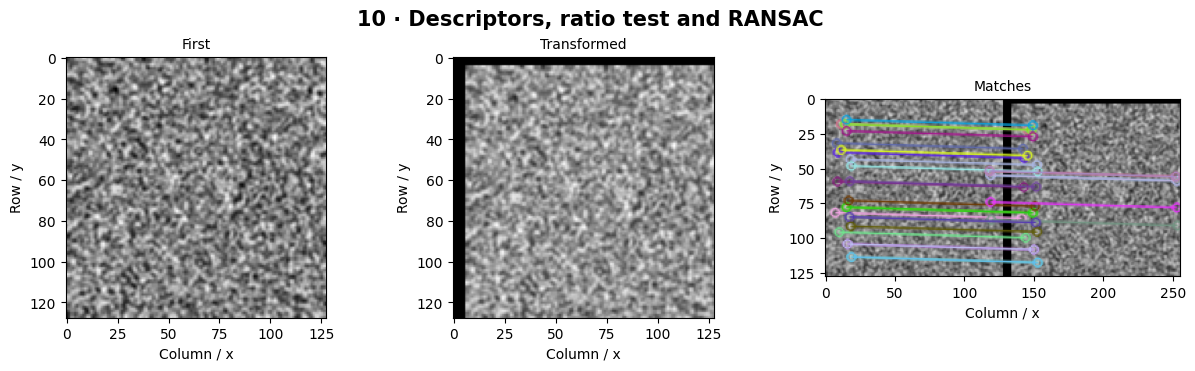

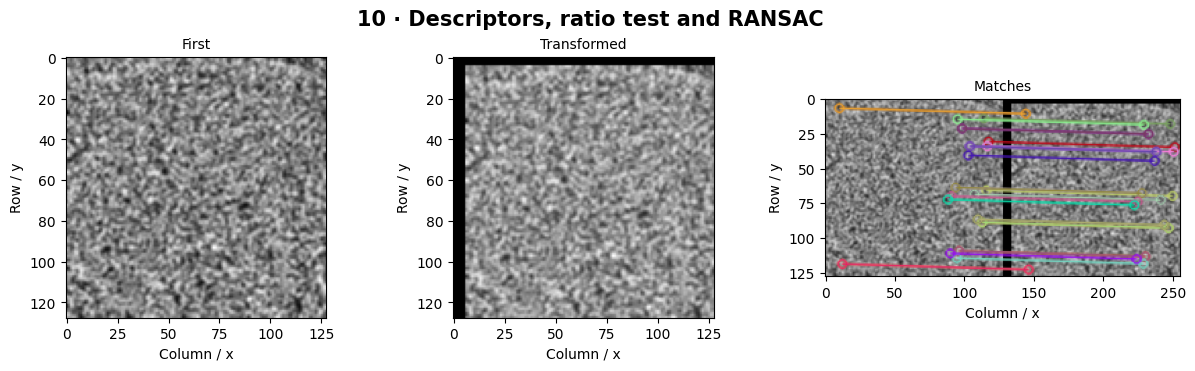

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Image Stitching System**. Reject false matches before estimating a geometric map. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Drawing many lines between two images can conceal false correspondences. A low residual on a tiny cluster of points may extrapolate badly.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Add repeated tiles and increase viewpoint change. Record keypoints, accepted matches, inliers and reprojection error separately.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a two-image stitcher that refuses weak geometry, reports inlier coverage and blends only a valid overlap.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

The ratio test compares the nearest match distance with the second nearest. A ratio near one means the best candidate is ambiguous. Cross-checking asks whether the match is mutual; it is a different filter. Neither resolves repeated texture or guarantees a correct correspondence.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **RANSAC homography and stitching** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)